<a href="https://colab.research.google.com/github/rakssan/genai-image-colorization/blob/main/colorization_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: GenAI Image Colorization

## 1. Project Overview

- Problem Statement:
  Black-and-white images lose important visual details and emotional impact.
  This project aims to automatically restore colors to grayscale images using a deep learning model.

- Real World Use Case:
  Useful for restoring old photos, enhancing historical archives, improving film restoration,
  and generating visually appealing color versions of monochrome images.
  Can also help artists and content creators.

- Goal of This Project:
  To build a CNN-based model that takes a grayscale image as input and predicts realistic
  color information by learning patterns from a dataset of colored images.

- Expected Output:
  A working machine learning model that accepts a grayscale image and outputs a fully colorized
  RGB image, displayed inside the notebook.


## GenAI Image Colorization - Project Journal

This notebook contains all experiments, ideas, and progress for building a deep learning model that colorizes black-and-white images.


## 1. Project Understanding
This project aims to build a deep learning model that automatically adds color to black-and-white images.
The goal is to learn how grayscale image pixels map to realistic colors using Convolutional Neural Networks (CNNs)
and modern image processing techniques. The final output should generate visually appealing colorized images.


## 2. Dataset Planning
For this project, I will use a simple and beginner-friendly dataset for image colorization.
The dataset will contain color images, and I will convert them into grayscale during preprocessing.

Dataset options I can use:
1. CIFAR-10 dataset (small, easy to load, good for practice)
2. Places365 small dataset (scenes with good variety)
3. Custom folder of images (any 100–500 images downloaded from the internet)

For the first version of the model, I will use CIFAR-10 because:
- It is available directly from TensorFlow and PyTorch
- Easy to load in Google Colab
- Good for quick training
- Light dataset so no GPU overload

Later, I can switch to higher-resolution datasets if needed.


## 3. Model Approach
The model will take a grayscale image as input and predict the missing color channels.
To do this, I will convert the color images into the LAB color space:

- L = Lightness (grayscale)
- A = Color channel 1 (green–red axis)
- B = Color channel 2 (blue–yellow axis)

Model Input:
- Only the L channel (grayscale image)

Model Output:
- Predict the A and B color channels

Model Architecture:
- I will use a simple Convolutional Neural Network (CNN) with:
  - Encoder: extracts features from the grayscale image
  - Decoder: reconstructs the color channels (A, B)
  - Activation functions: ReLU + tanh
  - Loss function: Mean Squared Error (MSE)

Why this approach:
- LAB color space separates lightness from color
- Easier for the model to learn missing colors rather than the full RGB image
- CNN-based encoder–decoder is simple and works well for beginners

After prediction:
- Combine the L channel + predicted A and B channels
- Convert back to RGB to display the final colorized image


In [1]:
# Step 1: Basic Imports
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
# Check GPU availability
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


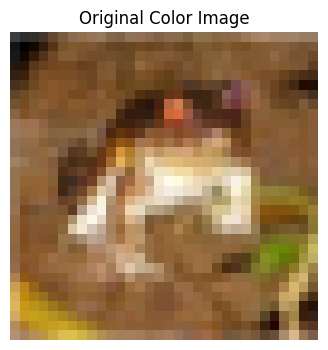

In [3]:
# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Show a sample image
sample = x_train[0]

plt.figure(figsize=(4,4))
plt.imshow(sample)
plt.title("Original Color Image")
plt.axis("off")
plt.show()


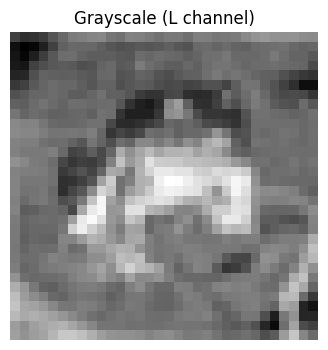

In [4]:
# Convert to LAB color space
lab = cv2.cvtColor((sample * 255).astype("uint8"), cv2.COLOR_RGB2LAB)

L, A, B = cv2.split(lab)

# Show L channel (grayscale)
plt.figure(figsize=(4,4))
plt.imshow(L, cmap="gray")
plt.title("Grayscale (L channel)")
plt.axis("off")
plt.show()


In [5]:
import os
from glob import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path to your uploaded images
image_paths = glob("/content/data/images/*")

print("Total images found:", len(image_paths))
image_paths[:5]


Total images found: 0


[]

In [6]:
def load_and_resize(path, size=(128,128)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img.astype("float32") / 255.0
    return img

# Try loading one image
sample = load_and_resize(image_paths[0])

plt.imshow(sample)
plt.title("Sample Color Image")
plt.axis("off")
plt.show()


IndexError: list index out of range

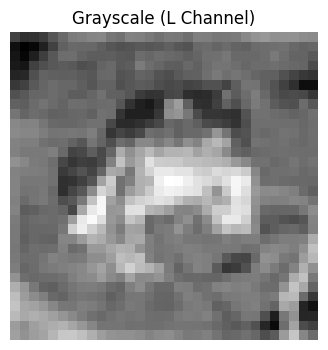

In [7]:
lab = cv2.cvtColor((sample * 255).astype("uint8"), cv2.COLOR_RGB2LAB)
L, A, B = cv2.split(lab)

plt.figure(figsize=(4,4))
plt.imshow(L, cmap="gray")
plt.title("Grayscale (L Channel)")
plt.axis("off")
plt.show()


In [8]:
# Empty lists to store L channel (input) and AB channels (output)
L_list = []
AB_list = []

for path in image_paths:
    img = load_and_resize(path)

    # Convert RGB → LAB
    lab = cv2.cvtColor((img * 255).astype("uint8"), cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)

    # Normalize A and B to [-1, 1]
    A = A / 128 - 1
    B = B / 128 - 1

    L_list.append(L)
    AB_list.append(np.stack((A, B), axis=-1))


# Convert to numpy arrays
L_list = np.array(L_list)
AB_list = np.array(AB_list)

print("L shape:", L_list.shape)
print("AB shape:", AB_list.shape)


L shape: (0,)
AB shape: (0,)


In [9]:
# Add channel dimension for model input
L_list = L_list.reshape(L_list.shape[0], 128, 128, 1)

print("New L shape:", L_list.shape)


New L shape: (0, 128, 128, 1)


In [10]:
from tensorflow.keras.layers import Input, Conv2D, UpSampling2D, Activation
from tensorflow.keras.models import Model

def build_colorization_model():

    # ----- Encoder -----
    input_l = Input(shape=(128,128,1))

    # Block 1
    e1 = Conv2D(64, (3,3), activation='relu', padding='same')(input_l)
    e1 = Conv2D(64, (3,3), activation='relu', padding='same')(e1)

    # Block 2
    e2 = Conv2D(128, (3,3), activation='relu', padding='same', strides=2)(e1)

    # Block 3
    e3 = Conv2D(256, (3,3), activation='relu', padding='same', strides=2)(e2)

    # ----- Decoder -----
    d1 = UpSampling2D((2,2))(e3)
    d1 = Conv2D(128, (3,3), activation='relu', padding='same')(d1)

    d2 = UpSampling2D((2,2))(d1)
    d2 = Conv2D(64, (3,3), activation='relu', padding='same')(d2)

    # Output layer: 2 channels (A & B)
    output_ab = Conv2D(2, (3,3), activation='tanh', padding='same')(d2)

    model = Model(inputs=input_l, outputs=output_ab)

    return model

model = build_colorization_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 2)    │         1,154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 776,578 (2.96 MB)

 Trainable params: 776,578 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(
    L_list,
    AB_list,
    batch_size=4,
    epochs=50,
    validation_split=0.1
)


ValueError: Training data contains 0 samples, which is not sufficient to split it into a validation and training set as specified by `validation_split=0.1`. Either provide more data, or a different value for the `validation_split` argument.